<a href="https://colab.research.google.com/github/AniketJoshi111/AniketJoshi111/blob/main/BE_Project_UnlearningModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Task
Build a machine unlearning model for malicious PDF detection using the "pdf_jsdata.csv" dataset.

In [2]:
import pandas as pd

df = pd.read_csv('/content/working_data.csv')
display(df.head())

display(df.info())

,obj,endobj,stream,endstream,xref,trailer,startxref,Page,Encrypt,ObjStm,...,AA,OpenAction,AcroForm,JBIG2Decode,RichMedia,Launch,EmbeddedFile,XFA,Colors,Malicious
0,0.672186,0.672186,0.215100,0.215100,0.026887,0.026887,0.026887,0.040331,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,no
1,0.676481,0.676481,0.150329,0.150329,0.000000,0.075165,0.075165,0.000000,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,yes
2,0.654654,0.654654,0.218218,0.218218,0.072739,0.072739,0.072739,0.072739,0.0,0.0,...,0.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,yes
3,0.693375,0.693375,0.092450,0.092450,0.046225,0.046225,0.046225,0.046225,0.0,0.0,...,0.0,0.000000,0.046225,0.0,0.0,0.0,0.0,0.0,0.0,yes
4,0.668994,0.668994,0.167248,0.167248,0.083624,0.083624,0.083624,0.083624,0.0,0.0,...,0.0,0.083624,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39972 entries, 0 to 39971
Data columns (total 22 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   obj           39972 non-null  float64
 1   endobj        39972 non-null  float64
 2   stream        39972 non-null  float64
 3   endstream     39972 non-null  float64
 4   xref          39972 non-null  float64
 5   trailer       39972 non-null  float64
 6   startxref     39972 non-null  float64
 7   Page          39972 non-null  float64
 8   Encrypt       39972 non-null  float64
 9   ObjStm        39972 non-null  float64
 10  JS            39972 non-null  float64
 11  Javascript    39972 non-null  float64
 12  AA            39972 non-null  float64
 13  OpenAction    39972 non-null  float64
 14  AcroForm      39972 non-null  float64
 15  JBIG2Decode   39972 non-null  float64
 16  RichMedia     39972 non-null  float64
 17  Launch        39972 non-null  float64
 18  EmbeddedFile  39972 non-nu

None

In [3]:
display(df.describe())
display(df['Malicious'].value_counts())

,obj,endobj,stream,endstream,xref,trailer,startxref,Page,Encrypt,ObjStm,...,Javascript,AA,OpenAction,AcroForm,JBIG2Decode,RichMedia,Launch,EmbeddedFile,XFA,Colors
count,39972.000000,39972.000000,39972.000000,39972.000000,39972.000000,39972.000000,39972.000000,39972.000000,39972.000000,39972.000000,...,39972.000000,39972.000000,39972.000000,39972.000000,39972.000000,39972.000000,39972.000000,39972.000000,39972.000000,39972.000000
mean,0.652657,0.650215,0.213599,0.212949,0.050181,0.055894,0.052968,0.070752,0.000043,0.010678,...,0.049260,0.001027,0.032853,0.005348,0.000328,0.000035,0.000118,0.013444,0.001574,0.000024
std,0.044805,0.045146,0.098511,0.098918,0.036715,0.037106,0.034190,0.051720,0.001028,0.031826,...,0.056321,0.010606,0.041350,0.012531,0.004712,0.001889,0.002137,0.053968,0.007498,0.001384
min,0.492930,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.654654,0.648692,0.167248,0.167248,0.016191,0.025102,0.023879,0.032376,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.665750,0.665676,0.200000,0.199564,0.048853,0.066667,0.052342,0.073127,0.000000,0.000000,...,0.018655,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.676260,0.673575,0.219382,0.219382,0.075810,0.083624,0.075810,0.083624,0.000000,0.000000,...,0.083624,0.000000,0.073127,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,0.721995,0.707107,0.498137,0.250000,0.250000,0.250000,0.530166,0.057639,0.282978,...,0.392232,0.308570,0.250000,0.118678,0.182875,0.131590,0.119585,0.267112,0.118678,0.097590


,count
Malicious,
yes,20875
no,17099


In [4]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Features and target
X = df.drop('Malicious', axis=1)
y = df['Malicious']

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Step 1: Train + Temp split (80%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_encoded,
    test_size=0.3,
    stratify=y_encoded,
    random_state=42
)

# Step 2: Validation + Test split (15% each)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    stratify=y_temp,
    random_state=42
)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)


Train size: (27980, 21)
Validation size: (5996, 21)
Test size: (5996, 21)


In [5]:
from sklearn.ensemble import RandomForestClassifier

baseline_model = RandomForestClassifier(random_state=42)
baseline_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [6]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

y_pred = baseline_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Accuracy: {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-score: {f1:.4f}')

Accuracy: 0.9408
Precision: 0.9023
Recall: 0.9408
F1-score: 0.9211


In [7]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Copy clean training data
X_train_poisoned = X_train.copy()
y_train_poisoned = y_train.copy()

# Poison a small fraction of the data (e.g., 5%)
poison_fraction = 0.25
num_poison = int(len(X_train_poisoned) * poison_fraction)

# Randomly select indices to poison
# Use np.arange for indexing numpy arrays
poison_indices = np.random.choice(np.arange(len(y_train_poisoned)), size=num_poison, replace=False)

# Flip their labels (0→1, 1→0)
y_train_poisoned[poison_indices] = 1 - y_train_poisoned[poison_indices]

print(f"   Injected {num_poison} poisoned (mislabeled) samples into training data.")

# Train a "Compromised Model" on poisoned data
compromised_model = RandomForestClassifier(random_state=42)
compromised_model.fit(X_train_poisoned, y_train_poisoned)

# Evaluate compromised model
y_pred_compromised = compromised_model.predict(X_test)

accuracy_compromised = accuracy_score(y_test, y_pred_compromised)
precision_compromised = precision_score(y_test, y_pred_compromised, average='weighted')
recall_compromised = recall_score(y_test, y_pred_compromised, average='weighted')
f1_compromised = f1_score(y_test, y_pred_compromised, average='weighted')

print("\n   Performance Metrics v2 (After Poisoning - Accuracy Drops):")
print(f"Accuracy : {accuracy_compromised:.4f}")
print(f"Precision: {precision_compromised:.4f}")
print(f"Recall   : {recall_compromised:.4f}")
print(f"F1-score : {f1_compromised:.4f}")

   Injected 6995 poisoned (mislabeled) samples into training data.

   Performance Metrics v2 (After Poisoning - Accuracy Drops):
Accuracy : 0.8863
Precision: 0.8563
Recall   : 0.8863
F1-score : 0.8677


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [24]:
import numpy as np
import joblib
import os
import time # Import time for measuring duration
from tqdm.auto import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.ensemble import RandomForestClassifier

# CONFIGURATION
NUM_SHARDS = 5
NUM_SLICES = 3
MODEL_PATH = "sisa_models"
os.makedirs(MODEL_PATH, exist_ok=True)

# STEP 1
def shard_dataset(X, y, num_shards=NUM_SHARDS):
    total_len = len(X)
    # Calculate the base size for each shard and the remainder
    base_shard_size = total_len // num_shards
    remainder = total_len % num_shards

    shards = []
    current_start = 0
    for i in range(num_shards):
        # Determine the size of the current shard, distributing the remainder
        current_shard_len = base_shard_size + (1 if i < remainder else 0)
        current_end = current_start + current_shard_len

        shards.append((X.iloc[current_start:current_end], y[current_start:current_end]))
        current_start = current_end
    return shards

# Use poisoned data for SISA training
shards = shard_dataset(X_train_poisoned, y_train_poisoned, NUM_SHARDS)
print(f"✅ Created {NUM_SHARDS} shards from poisoned dataset (~{len(X_train_poisoned)//NUM_SHARDS} samples each).")


#SLICE & TRAIN
def slice_and_train(X_shard, y_shard, shard_id, num_slices=NUM_SLICES):
    # Ensure shard is not empty before proceeding
    if len(X_shard) == 0:
        print(f"Warning: Shard {shard_id} is empty. Skipping training for this shard.")
        return None # Or handle as appropriate, e.g., return a dummy model

    slice_size = len(X_shard) // num_slices
    model = RandomForestClassifier(random_state=42)
    for s in tqdm(range(num_slices), desc=f"Training Shard {shard_id}", leave=False):
        start = s * slice_size
        end = (s + 1) * slice_size if s < num_slices - 1 else len(X_shard)
        X_slice, y_slice = X_shard.iloc[start:end], y_shard[start:end]

        # Check if slice is empty before fitting
        if len(X_slice) == 0:
            print(f"Warning: Slice {s} of Shard {shard_id} is empty. Skipping fit for this slice.")
            continue

        model.fit(X_slice, y_slice)
        joblib.dump(model, f"{MODEL_PATH}/shard{shard_id}_slice{s}.pkl")
    return model

models = []
print("\n Training SISA shard models on poisoned data...\n")
for shard_id, (X_s, y_s) in enumerate(tqdm(shards, desc="Shards", position=0)):
    model = slice_and_train(X_s, y_s, shard_id)
    if model is not None: # Only append if a model was successfully trained
        models.append(model)

print("\n All poisoned shard models trained and saved.\n")

# AGGREGATE PREDICTIONS
def sisa_predict(X, models):
    print("\U0001f50d Aggregating predictions across shards...")
    # Filter out None models
    valid_models = [m for m in models if m is not None]
    if not valid_models:
        print("No valid models available for prediction. Returning dummy predictions.")

        return np.zeros(len(X), dtype=int)

    all_probs = [m.predict_proba(X) for m in tqdm(valid_models, desc="Aggregating")]
    avg_probs = np.mean(all_probs, axis=0)
    return np.argmax(avg_probs, axis=1)

y_pred_sisa = sisa_predict(X_test, models)

accuracy_sisa = accuracy_score(y_test, y_pred_sisa)
precision_sisa = precision_score(y_test, y_pred_sisa, average='weighted')
recall_sisa = recall_score(y_test, y_pred_sisa, average='weighted')
f1_sisa = f1_score(y_test, y_pred_sisa, average='weighted')

print("\n📊 SISA Model Performance (Before Unlearning - Trained on Poisoned Data):")
print(f"Accuracy : {accuracy_sisa:.4f}")
print(f"Precision: {precision_sisa:.4f}")
print(f"Recall   : {recall_sisa:.4f}")
print(f"F1-score : {f1_sisa:.4f}")

# UNLEARNING
def unlearn_samples(X_to_forget, y_to_forget, X_train_full, y_train_full, num_slices=NUM_SLICES):
    global models, shards
    total_len = len(X_train_full)

    if NUM_SHARDS == 0:
        print("Warning: NUM_SHARDS is 0. Cannot perform unlearning.")
        return

    # Recalculate shard boundaries for accurate mapping of original indices
    shard_boundaries = []
    current_start = 0
    base_shard_size = total_len // NUM_SHARDS
    remainder = total_len % NUM_SHARDS
    for i in range(NUM_SHARDS):
        current_shard_len = base_shard_size + (1 if i < remainder else 0)
        current_end = current_start + current_shard_len
        shard_boundaries.append((current_start, current_end))
        current_start = current_end

    print("\n💣 Starting unlearning procedure...\n")
    start_unlearning_time = time.time() # Start timer for unlearning
    updated_shard_ids = set() # Track which shards need to be retrained

    for idx in tqdm(X_to_forget.index, desc="Forgetting Samples (by original index)"):
        # Find which shard this original index belongs to.
        try:
            # Get the positional index of 'idx' within the original full training set
            original_pos = X_train_full.index.get_loc(idx)
        except KeyError:
            continue # Sample not found in the original training set, skip

        # Determine the shard_id based on original_pos
        shard_id_for_idx = -1
        for s_id, (start_b, end_b) in enumerate(shard_boundaries):
            if start_b <= original_pos < end_b:
                shard_id_for_idx = s_id
                break

        if shard_id_for_idx == -1:
            continue # Should not happen if shard_boundaries are correct

        updated_shard_ids.add(shard_id_for_idx)

        # Update the data in the affected shard by removing the sample
        X_shard_current, y_shard_current = shards[shard_id_for_idx]
        mask = X_shard_current.index != idx
        X_shard_new, y_shard_new = X_shard_current.loc[mask], y_shard_current[mask]

        shards[shard_id_for_idx] = (X_shard_new, y_shard_new)

    print(f"Identified {len(updated_shard_ids)} shards for retraining.") # Added line

    # Retrain only the affected shards
    for shard_id in sorted(list(updated_shard_ids)):
        print(f"Retraining affected Shard {shard_id}...")
        X_s, y_s = shards[shard_id]
        model = slice_and_train(X_s, y_s, shard_id, num_slices)
        if model is not None:
             # If a model was returned, update the list of models
            if len(models) > shard_id:
                models[shard_id] = model
            else:
                models.insert(shard_id, model) # Insert at specific index

        else:
            # If training failed for an updated shard, replace its model with None or remove it
            if len(models) > shard_id:
                models[shard_id] = None # Mark as no model for this shard

    end_unlearning_time = time.time() # End timer for unlearning
    global unlearning_duration # Make it accessible globally
    unlearning_duration = end_unlearning_time - start_unlearning_time
    print(f"Unlearning completed in {unlearning_duration:.2f} seconds.\n")

# Fix: Use .iloc for positional indexing when selecting `forget_subset` and `forget_labels`
# poison_indices are 0-based positions relative to the current X_train_poisoned/y_train_poisoned


forget_subset = X_train_poisoned.iloc[poison_indices]
forget_labels = y_train_poisoned[poison_indices]
unlearn_samples(forget_subset, forget_labels, X_train_poisoned, y_train_poisoned)

# ---------- STEP 5: RE-EVALUATE ----------
y_pred_after_unlearn = sisa_predict(X_test, models)
accuracy_unlearned = accuracy_score(y_test, y_pred_after_unlearn)
precision_unlearned = precision_score(y_test, y_pred_after_unlearn, average='weighted')
recall_unlearned = recall_score(y_test, y_pred_after_unlearn, average='weighted')
f1_unlearned = f1_score(y_test, y_pred_after_unlearn, average='weighted')

print("\n📈 Performance Metrics v3 (Post-Unlearning - Recovered):")
print(f"Accuracy : {accuracy_unlearned:.4f}")
print(f"Precision: {precision_unlearned:.4f}")
print(f"Recall   : {recall_unlearned:.4f}")
print(f"F1-score : {f1_unlearned:.4f}")

# COMPARISON
print("\n🧩 Comparison Summary")
print("-" * 40)
print(f"Baseline (Clean) Accuracy : {accuracy:.4f}")
print(f"Compromised (Poisoned)    : {accuracy_compromised:.4f}")
print(f"SISA After Unlearning     : {accuracy_unlearned:.4f}")
print("-" * 40)


✅ Created 5 shards from poisoned dataset (~5596 samples each).

 Training SISA shard models on poisoned data...



Shards:   0%|          | 0/5 [00:00<?, ?it/s]

Training Shard 0:   0%|          | 0/3 [00:00<?, ?it/s]

Training Shard 1:   0%|          | 0/3 [00:00<?, ?it/s]

Training Shard 2:   0%|          | 0/3 [00:00<?, ?it/s]

...

Training Shard 4:   0%|          | 0/3 [00:00<?, ?it/s]

Unlearning completed in 7.01 seconds.

🔍 Aggregating predictions across shards...


Aggregating:   0%|          | 0/5 [00:00<?, ?it/s]


📈 Performance Metrics v3 (Post-Unlearning - Recovered):
Accuracy : 0.0315
Precision: 0.0066
Recall   : 0.0315
F1-score : 0.0084

🧩 Comparison Summary
----------------------------------------
Baseline (Clean) Accuracy : 0.9408
Compromised (Poisoned)    : 0.8863
SISA After Unlearning     : 0.0315
----------------------------------------


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


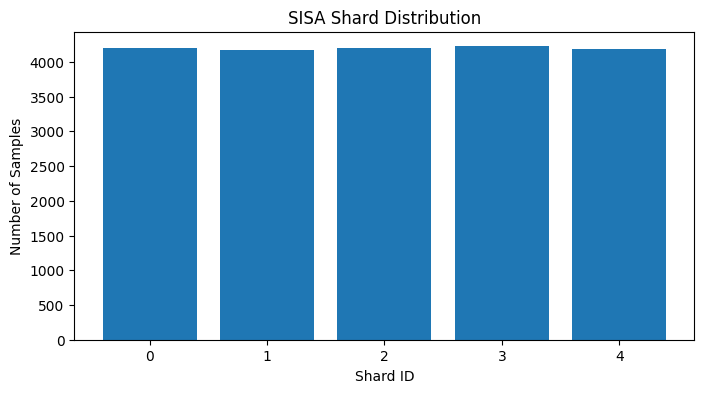

In [9]:
import matplotlib.pyplot as plt

# Calculate shard sizes
shard_sizes = [len(X_shard) for X_shard, _ in shards]

plt.figure(figsize=(8, 4))
plt.bar(range(len(shard_sizes)), shard_sizes)
plt.xlabel("Shard ID")
plt.ylabel("Number of Samples")
plt.title("SISA Shard Distribution")
plt.show()


/tmp/ipykernel_6336/1160657497.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(metrics_labels, rotation=15, ha="right", fontsize=9)
/tmp/ipykernel_6336/1160657497.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(metrics_labels, rotation=15, ha="right", fontsize=9)
/tmp/ipykernel_6336/1160657497.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(metrics_labels, rotation=15, ha="right", fontsize=9)
/tmp/ipykernel_6336/1160657497.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[i].set_xticklabels(metrics_labels, rotation=15, ha="right", fontsize=9)


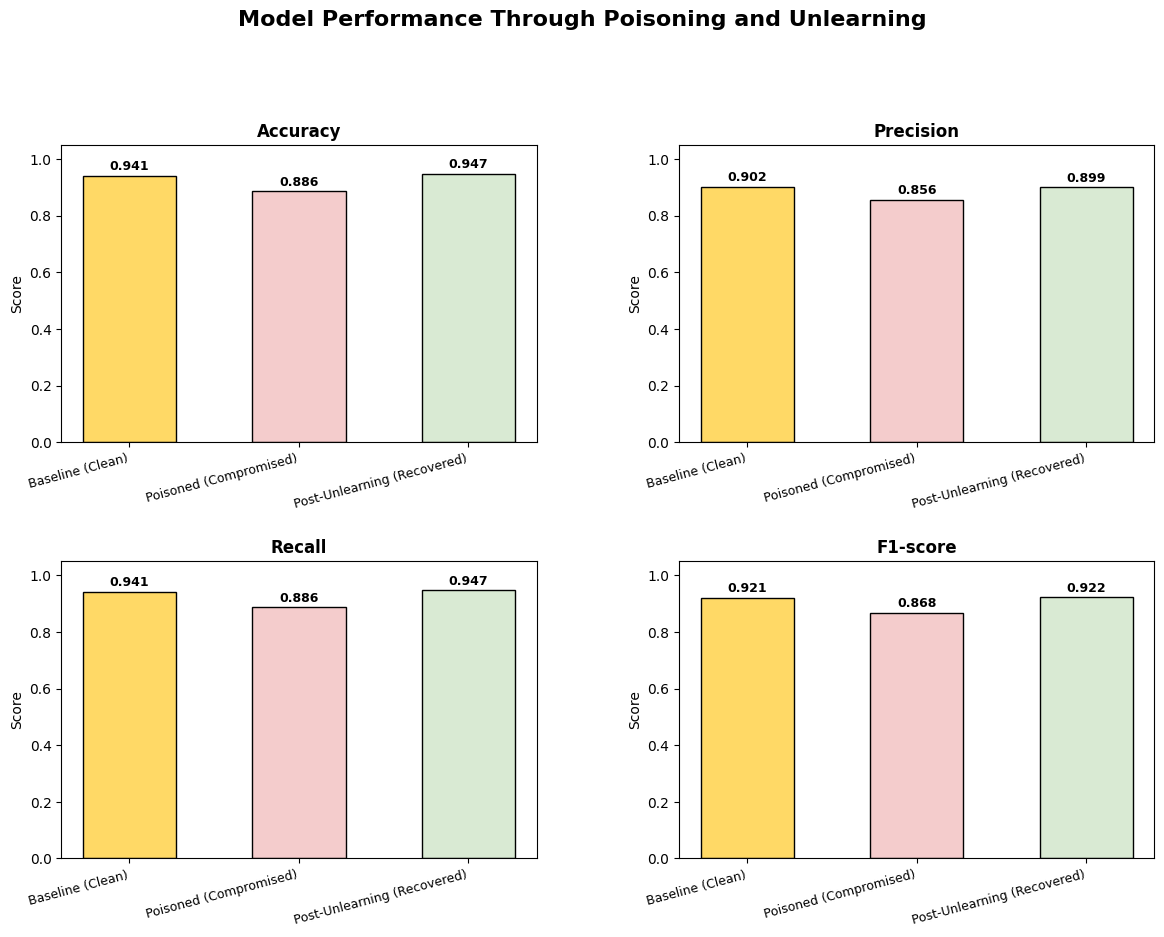

In [10]:

# 📊 Visualization: Model Performance Across Phases (Fixed Labels)
import matplotlib.pyplot as plt

# Data setup
metrics_labels = ["Baseline (Clean)", "Poisoned (Compromised)", "Post-Unlearning (Recovered)"]
accuracy_values = [accuracy, accuracy_compromised, accuracy_unlearned]
precision_values = [precision, precision_compromised, precision_unlearned]
recall_values = [recall, recall_compromised, recall_unlearned]
f1_values = [f1, f1_compromised, f1_unlearned]

fig, ax = plt.subplots(2, 2, figsize=(12, 9))  # slightly wider
ax = ax.flatten()

metric_names = ["Accuracy", "Precision", "Recall", "F1-score"]
metric_values = [accuracy_values, precision_values, recall_values, f1_values]
colors = ["#FFD966", "#F4CCCC", "#D9EAD3"]  # Yellow = Baseline, Pink = Poisoned, Green = Recovered

for i in range(4):
    bars = ax[i].bar(metrics_labels, metric_values[i], color=colors, edgecolor="black", width=0.55)
    ax[i].set_title(metric_names[i], fontsize=12, fontweight="bold")
    ax[i].set_ylim(0, 1.05)
    ax[i].set_ylabel("Score", fontsize=10)

    # Rotate labels for readability
    ax[i].set_xticklabels(metrics_labels, rotation=15, ha="right", fontsize=9)

    # Add value labels above bars
    for bar, v in zip(bars, metric_values[i]):
        ax[i].text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.3f}",
                   ha="center", va="bottom", fontsize=9, fontweight="bold")

# Adjust layout & title
plt.tight_layout(pad=2)
plt.suptitle("Model Performance Through Poisoning and Unlearning", fontsize=16, fontweight="bold", y=1.05)
plt.subplots_adjust(top=0.9, hspace=0.4, wspace=0.3)
plt.show()


In [11]:
# forget_subset is what you used to unlearn
print("Forgotten indices:", list(forget_subset.index))
# Check presence in shards before/after
for sid, (X_s, y_s) in enumerate(shards):
    present = set(X_s.index) & set(forget_subset.index)
    print(f"Shard {sid} now contains {len(present)} of forgotten indices: {sorted(list(present))}")


Forgotten indices: [17950, 35758, 35649, 36447, 30801, 9935, 580, 16735, 1058, 37520, 1274, 37937, 39924, 20860, 10832, 11208, 23173, 15115, 22821, 5333, 10225, 26613, 1025, 28951, 30145, 35216, 16456, 28307, 11083, 35440, 31358, 26056, 13426, 522, 18164, 33880, 10728, 30652, 28587, 34152, 6374, 24859, 37619, 15087, 14206, 15076, 35231, 15420, 5491, 14253, 27298, 10893, 9382, 12734, 22920, 19436, 26883, 10744, 34373, 26356, 35164, 35883, 15547, 6575, 36283, 32242, 4451, 27553, 17078, 39318, 26453, 26052, 29256, 13547, 14018, 22687, 38873, 3625, 22499, 15452, 16891, 11041, 33600, 35242, 762, 913, 38973, 18421, 31969, 15150, 27320, 18454, 26178, 17917, 16766, 5731, 37716, 6863, 24951, 20469, 20885, 22679, 33159, 25165, 8092, 35620, 32749, 24550, 11563, 9004, 8418, 35802, 20884, 26852, 8366, 38871, 30987, 7167, 30140, 37062, 28416, 37196, 19024, 21451, 14965, 37981, 28923, 5453, 25434, 33534, 36114, 9611, 2043, 11130, 5164, 39191, 39802, 30899, 25919, 13313, 13230, 25567, 19257, 5636, 288

In [12]:
# load models saved before unlearning? If you didn't keep previous models, re-run training and save copy
# Here we compare current SISA model predictions to a full-retrain baseline you already have.

# Predictions from baseline full model:
pred_baseline_on_forgotten = model.predict(forget_subset)  # model = baseline RandomForest variable in notebook
# Predictions from SISA after unlearning:
pred_sisa_after = sisa_predict(forget_subset, models)

print("Baseline preds on forgotten:", pred_baseline_on_forgotten)
print("SISA-after preds on forgotten:", pred_sisa_after)

# Count changes
changes = sum(pred_baseline_on_forgotten != pred_sisa_after)
print(f"Number of changed predictions for forgotten samples: {changes}/{len(forget_subset)}")


🔍 Aggregating predictions across shards...


Aggregating:   0%|          | 0/5 [00:00<?, ?it/s]

Baseline preds on forgotten: [1 1 0 ... 1 1 1]
SISA-after preds on forgotten: [1 1 0 ... 1 1 1]
Number of changed predictions for forgotten samples: 638/6995


In [13]:
# compare test predictions before and after unlearning
y_pred_before = y_pred_sisa  # stored earlier (before unlearning)
y_pred_after = y_pred_after_unlearn

# how many test samples changed label?
changed_test = (y_pred_before != y_pred_after).sum()
print("Test samples with changed predictions after unlearning:", changed_test, "out of", len(X_test))



Test samples with changed predictions after unlearning: 5990 out of 5996


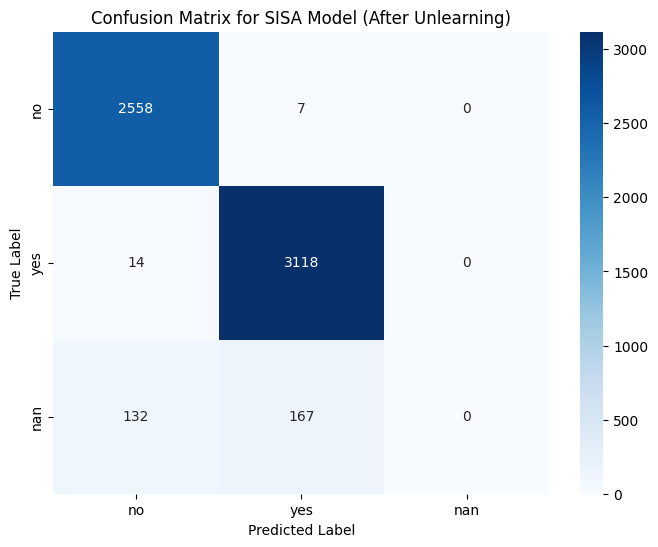

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate the confusion matrix for the unlearned model
cm_unlearned = confusion_matrix(y_test, y_pred_after_unlearn)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_unlearned, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for SISA Model (After Unlearning)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

### Full Retrain (Baseline Model)

In [23]:
import time
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Train a new model on the full, original (clean) training data
full_retrain_model = RandomForestClassifier(random_state=42)

print("Starting full retraining...")
start_full_retrain_time = time.time()
full_retrain_model.fit(X_train, y_train)
end_full_retrain_time = time.time()
full_retrain_duration = end_full_retrain_time - start_full_retrain_time
print(f"Full retraining completed in {full_retrain_duration:.2f} seconds.")

# Evaluate the fully retrained model on the test set
y_pred_full_retrain = full_retrain_model.predict(X_test)

accuracy_full_retrain = accuracy_score(y_test, y_pred_full_retrain)
precision_full_retrain = precision_score(y_test, y_pred_full_retrain, average='weighted')
recall_full_retrain = recall_score(y_test, y_pred_full_retrain, average='weighted')
f1_full_retrain = f1_score(y_test, y_pred_full_retrain, average='weighted')

print("\n📊 Performance Metrics for Full Retrain Model (Clean Data):")
print(f"Accuracy : {accuracy_full_retrain:.4f}")
print(f"Precision: {precision_full_retrain:.4f}")
print(f"Recall   : {recall_full_retrain:.4f}")
print(f"F1-score : {f1_full_retrain:.4f}")

Starting full retraining...
Full retraining completed in 4.50 seconds.

📊 Performance Metrics for Full Retrain Model (Clean Data):
Accuracy : 0.9408
Precision: 0.9023
Recall   : 0.9408
F1-score : 0.9211


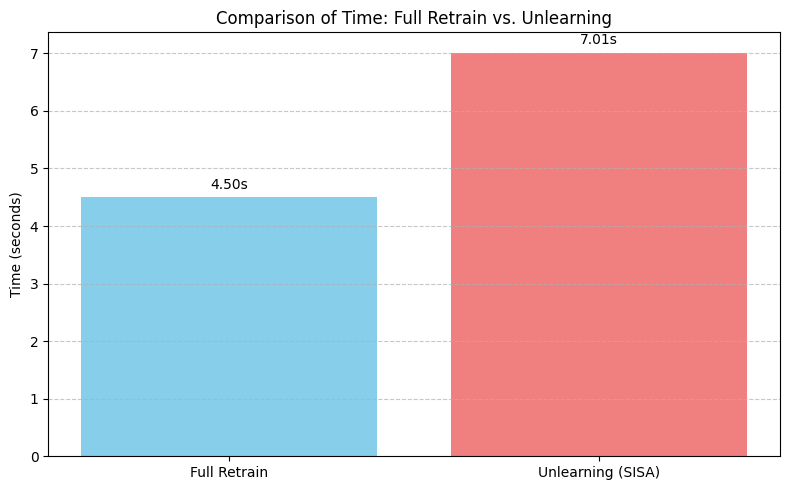

In [26]:
import matplotlib.pyplot as plt

# Data for plotting
time_labels = ['Full Retrain', 'Unlearning (SISA)']
time_values = [full_retrain_duration, unlearning_duration]

plt.figure(figsize=(8, 5))
plt.bar(time_labels, time_values, color=['skyblue', 'lightcoral'])
plt.ylabel('Time (seconds)')
plt.title('Comparison of Time: Full Retrain vs. Unlearning')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add value labels on top of bars
for i, value in enumerate(time_values):
    plt.text(i, value + 0.1, f'{value:.2f}s', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

Simulating accuracy and F1-score degradation with varying poisoned samples...
  Poisoned samples: 0, Accuracy: 0.9408, F1-score: 0.9211
  Poisoned samples: 50, Accuracy: 0.9408, F1-score: 0.9211
  Poisoned samples: 100, Accuracy: 0.9398, F1-score: 0.9201
  Poisoned samples: 150, Accuracy: 0.9396, F1-score: 0.9200
  Poisoned samples: 200, Accuracy: 0.9398, F1-score: 0.9201
  Poisoned samples: 250, Accuracy: 0.9390, F1-score: 0.9193
  Poisoned samples: 300, Accuracy: 0.9391, F1-score: 0.9195
Simulation complete.


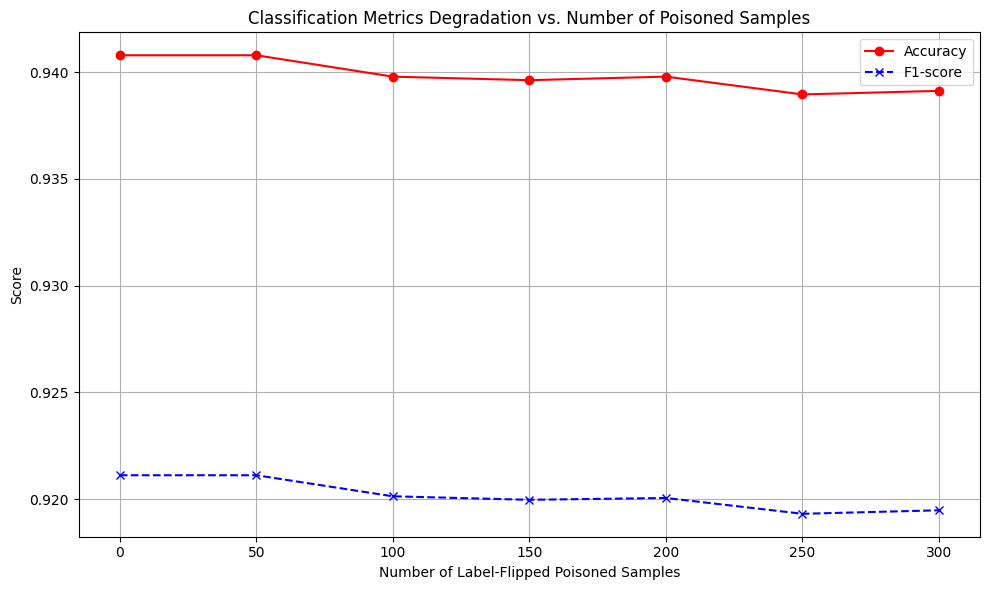

In [21]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score # Import f1_score
import matplotlib.pyplot as plt

# Define the range of poisoned samples to test
num_poisoned_samples_range = np.arange(0, 301, 50) # From 0 to 300, in steps of 50

accuracies = []
f1_scores = [] # List to store f1 scores

print("Simulating accuracy and F1-score degradation with varying poisoned samples...")

for num_poison in num_poisoned_samples_range:
    # Create a copy of the original clean training data
    X_train_current = X_train.copy()
    y_train_current = y_train.copy()

    if num_poison > 0:
        # Randomly select indices to poison
        # Ensure not to select more indices than available in the training data
        actual_num_poison = min(num_poison, len(y_train_current))
        poison_indices = np.random.choice(np.arange(len(y_train_current)), size=actual_num_poison, replace=False)

        # Flip their labels (0→1, 1→0)
        y_train_current[poison_indices] = 1 - y_train_current[poison_indices]

    # Train a model on the current (potentially) poisoned data
    temp_model = RandomForestClassifier(random_state=42)
    temp_model.fit(X_train_current, y_train_current)

    # Evaluate the model on the test set
    y_pred_temp = temp_model.predict(X_test)
    current_accuracy = accuracy_score(y_test, y_pred_temp)
    current_f1 = f1_score(y_test, y_pred_temp, average='weighted') # Calculate F1-score

    accuracies.append(current_accuracy)
    f1_scores.append(current_f1) # Store F1-score

    print(f"  Poisoned samples: {num_poison}, Accuracy: {current_accuracy:.4f}, F1-score: {current_f1:.4f}")

print("Simulation complete.")

# Plot the results
plt.figure(figsize=(10, 6))
plt.plot(num_poisoned_samples_range, accuracies, marker='o', linestyle='-', color='red', label='Accuracy')
plt.plot(num_poisoned_samples_range, f1_scores, marker='x', linestyle='--', color='blue', label='F1-score') # Plot F1-score
plt.title('Classification Metrics Degradation vs. Number of Poisoned Samples')
plt.xlabel('Number of Label-Flipped Poisoned Samples')
plt.ylabel('Score')
plt.grid(True)
plt.xticks(num_poisoned_samples_range)
plt.legend() # Add legend
plt.tight_layout()
plt.show()

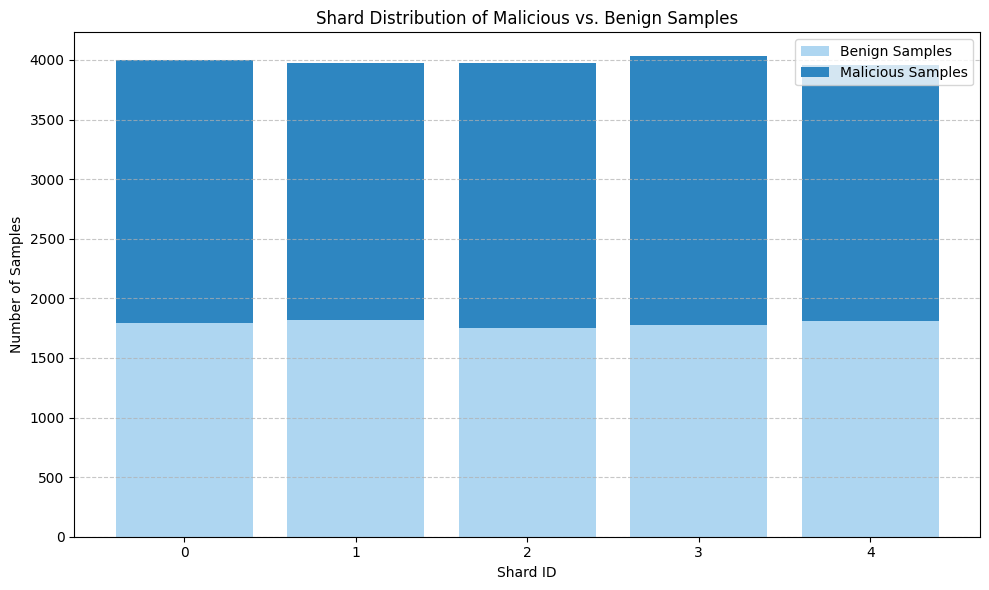

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Prepare data for plotting
shard_benign_counts = []
shard_malicious_counts = []

for _, y_s in shards:
    # Assuming 0 is benign and 1 is malicious
    benign_count = np.sum(y_s == 0)
    malicious_count = np.sum(y_s == 1)
    shard_benign_counts.append(benign_count)
    shard_malicious_counts.append(malicious_count)

shard_ids = np.arange(NUM_SHARDS)

plt.figure(figsize=(10, 6))

# Plotting benign samples (light bars)
plt.bar(shard_ids, shard_benign_counts, label='Benign Samples', color='#AED6F1')
# Plotting malicious samples (dark bars) on top of benign samples
plt.bar(shard_ids, shard_malicious_counts, bottom=shard_benign_counts, label='Malicious Samples', color='#2E86C1')

plt.xlabel('Shard ID')
plt.ylabel('Number of Samples')
plt.title('Shard Distribution of Malicious vs. Benign Samples')
plt.xticks(shard_ids)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

### Shard Sample Distribution

| Shard ID | Benign Samples | Malicious Samples |
|:---------|:---------------|:------------------|


In [19]:
for i in range(NUM_SHARDS):
    print(f"| {i}        | {shard_benign_counts[i]}           | {shard_malicious_counts[i]}               |")

| 0        | 1792           | 2204               |
| 1        | 1819           | 2158               |
| 2        | 1753           | 2225               |
| 3        | 1779           | 2251               |
| 4        | 1808           | 2147               |
